# RetailMind AI — Phase 6: Business Intelligence & Measurable Signals

**Module:** Retail Intelligence, KPI Engineering & Actionable Decision Signals  
**Notebook:** `notebook/06_business_signals_and_kpis.ipynb`  
**Input Datasets:**
- `data/processed/retail_cleaned.csv`
- `data/processed/customer_segments.csv`
- `data/processed/product_features.csv`
- `data/processed/daily_product_demand.csv`

**Generated Output Datasets:**
- `data/processed/monthly_product_demand.csv`
- `data/processed/monthly_business_kpis.csv`
- `data/processed/product_opportunity_risk.csv`
- `data/processed/customer_retention_risk.csv`

**Generated Visualizations:**
- `outputs/figures/monthly_revenue_trend.png`
- `outputs/figures/business_kpi_dashboard.png`
- `outputs/figures/product_opportunity_matrix.png`
- `outputs/figures/customer_churn_risk_distribution.png`

---
## 1. Objective & Business Architecture

Retail intelligence systems must bridge low-level transactional telemetry with high-level executive decision-making. While Phase 4 provides granular SKU-level demand forecasts and Phase 5 segments customer behavioral cohorts, this module aggregates and synthesizes these findings into **measurable, reproducible business signals**:

1. **Macro-Level Demand Aggregation:** Construct monthly product demand and seasonality indices for macro inventory and financial planning.
2. **Enterprise Business KPIs:** Track longitudinal retail health indicators across $5$ years ($2020 - 2024$), including Gross Merchandise Value (GMV), Net Realized Revenue, Average Order Value (AOV), Return Rates, and Cancellation Friction.
3. **Product Opportunity & Stockout Risk:** Quantify demand momentum, forecast volatility ($CV = \sigma / \mu$), and price realization to classify SKUs into proactive supply chain tiers.
4. **Customer Retention & Churn Risk:** Formulate an empirical purchase cycle model to measure overdue risk, churn probability, and customer loyalty indices without arbitrary scoring.

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Formatting and display options
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# Configure relative project paths
DATA_DIR = '../data/processed'
FIGURES_DIR = '../outputs/figures'

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

# File path definitions
RETAIL_CLEANED_PATH = os.path.join(DATA_DIR, 'retail_cleaned.csv')
CUSTOMER_SEGMENTS_PATH = os.path.join(DATA_DIR, 'customer_segments.csv')
PRODUCT_FEATURES_PATH = os.path.join(DATA_DIR, 'product_features.csv')

print("Environment configured successfully.")
print(f"  Target Data Directory   : {os.path.abspath(DATA_DIR)}")
print(f"  Target Figures Directory: {os.path.abspath(FIGURES_DIR)}")

Environment configured successfully.
  Target Data Directory   : D:\RetailMindAI\RetailMindAI\data\processed
  Target Figures Directory: D:\RetailMindAI\RetailMindAI\outputs\figures


In [2]:
# Ingest core processed datasets
df_retail = pd.read_csv(RETAIL_CLEANED_PATH)
df_retail['OrderDate'] = pd.to_datetime(df_retail['OrderDate'])

df_cust = pd.read_csv(CUSTOMER_SEGMENTS_PATH)
df_prod = pd.read_csv(PRODUCT_FEATURES_PATH)

print("=== Ingested Datasets Summary ===")
print(f"  retail_cleaned.csv    : {df_retail.shape[0]:,} rows x {df_retail.shape[1]} cols")
print(f"  customer_segments.csv : {df_cust.shape[0]:,} rows x {df_cust.shape[1]} cols")
print(f"  product_features.csv  : {df_prod.shape[0]:,} rows x {df_prod.shape[1]} cols")
print(f"  Date Range Spanned    : {df_retail['OrderDate'].min().strftime('%Y-%m-%d')} to {df_retail['OrderDate'].max().strftime('%Y-%m-%d')}")

=== Ingested Datasets Summary ===
  retail_cleaned.csv    : 100,000 rows x 26 cols
  customer_segments.csv : 43,233 rows x 16 cols
  product_features.csv  : 50 rows x 20 cols
  Date Range Spanned    : 2020-01-01 to 2024-12-29


---
## 2. Monthly Product Demand & Seasonality Modeling

We aggregate daily transactions by product and calendar month to model macro volume shifts, month-over-month (MoM) demand velocity, and seasonal indices:
$$\text{SeasonalIndex}_{i, m} = \frac{\text{MonthlyQuantity}_{i, m}}{\bar{Q}_i + \epsilon}$$
where $\bar{Q}_i$ is the average monthly volume for product $i$.

In [3]:
# Extract temporal period components
df_retail['YearMonth'] = df_retail['OrderDate'].dt.to_period('M').astype(str)
df_retail['Year'] = df_retail['OrderDate'].dt.year
df_retail['Month'] = df_retail['OrderDate'].dt.month

# Group transactions by Product and YearMonth
monthly_product_demand = df_retail.groupby(
    ['ProductID', 'ProductName', 'Category', 'YearMonth', 'Year', 'Month']
).agg(
    MonthlyQuantity=('Quantity', 'sum'),
    MonthlyRevenue=('TotalAmount', 'sum'),
    MonthlyOrderCount=('OrderID', 'nunique'),
    UniqueCustomers=('CustomerID', 'nunique'),
    AverageUnitPrice=('UnitPrice', 'mean'),
    AverageDiscount=('Discount', 'mean'),
    ReturnRate=('is_returned', 'mean'),
    CancellationRate=('is_cancelled', 'mean')
).reset_index()

# Sort sequentially by product and time
monthly_product_demand = monthly_product_demand.sort_values(['ProductID', 'YearMonth']).reset_index(drop=True)

# Compute MoM growth metrics
monthly_product_demand['MoM_QuantityGrowth'] = monthly_product_demand.groupby('ProductID')['MonthlyQuantity'].pct_change().fillna(0.0).round(4)
monthly_product_demand['MoM_RevenueGrowth'] = monthly_product_demand.groupby('ProductID')['MonthlyRevenue'].pct_change().fillna(0.0).round(4)

# Compute normalized seasonal index per product
prod_mean_vol = monthly_product_demand.groupby('ProductID')['MonthlyQuantity'].transform('mean')
monthly_product_demand['SeasonalIndex'] = (monthly_product_demand['MonthlyQuantity'] / (prod_mean_vol + 1e-5)).round(4)

print(f"Monthly Product Demand dataset created: {monthly_product_demand.shape[0]:,} rows x {monthly_product_demand.shape[1]} columns")
display(monthly_product_demand.head(5))

Monthly Product Demand dataset created: 17,931 rows x 17 columns


,ProductID,ProductName,Category,YearMonth,Year,Month,MonthlyQuantity,MonthlyRevenue,MonthlyOrderCount,UniqueCustomers,AverageUnitPrice,AverageDiscount,ReturnRate,CancellationRate,MoM_QuantityGrowth,MoM_RevenueGrowth,SeasonalIndex
0,P00001,Wireless Earbuds,Books,2020-01,2020,1,17,6503.6400,7,7,327.2643,0.0786,0.0000,0.1429,0.0000,0.0000,1.0158
1,P00001,Wireless Earbuds,Clothing,2020-01,2020,1,20,5780.4200,7,7,285.9986,0.0500,0.1429,0.0000,0.1765,-0.1112,1.1951
2,P00001,Wireless Earbuds,Electronics,2020-01,2020,1,15,4692.2100,4,4,266.2225,0.0125,0.0000,0.0000,-0.2500,-0.1883,0.8963
3,P00001,Wireless Earbuds,Home & Kitchen,2020-01,2020,1,30,11957.0100,10,10,373.9550,0.0800,0.0000,0.0000,1.0000,1.5483,1.7926
4,P00001,Wireless Earbuds,Sports & Outdoors,2020-01,2020,1,21,9994.3600,6,6,423.2600,0.0083,0.0000,0.0000,-0.3000,-0.1641,1.2548


---
## 3. Enterprise Retail KPI Analytics & Performance Drivers

We compute monthly longitudinal business KPIs across all operations, capturing:
- **Top-Line Volume:** Total Orders, Active Unique Customers, Units Sold
- **Financial Performance:** Gross Merchandise Value (GMV), Gross Discount Outlay, Net Realized Revenue
- **Unit Economics:** Average Order Value (AOV), Units per Order, Realized Net Price
- **Fulfillment Health:** Return Rate and Cancellation Rate

In [4]:
# Compute monthly enterprise KPIs
monthly_kpis = df_retail.groupby(['YearMonth', 'Year', 'Month']).agg(
    TotalOrders=('OrderID', 'nunique'),
    ActiveCustomers=('CustomerID', 'nunique'),
    TotalQuantitySold=('Quantity', 'sum'),
    GrossMerchandiseValue=('TotalAmount', 'sum'),
    AverageOrderValue=('TotalAmount', 'mean'),
    AverageUnitPrice=('UnitPrice', 'mean'),
    AverageDiscount=('Discount', 'mean'),
    ReturnedOrders=('is_returned', 'sum'),
    CancelledOrders=('is_cancelled', 'sum'),
    DeliveredOrders=('is_delivered', 'sum')
).reset_index()

monthly_kpis['ReturnRate'] = (monthly_kpis['ReturnedOrders'] / monthly_kpis['TotalOrders']).round(4)
monthly_kpis['CancellationRate'] = (monthly_kpis['CancelledOrders'] / monthly_kpis['TotalOrders']).round(4)
monthly_kpis['AverageUnitsPerOrder'] = (monthly_kpis['TotalQuantitySold'] / monthly_kpis['TotalOrders']).round(2)

# Compute gross discount amount: sum(Quantity * UnitPrice * Discount)
discount_by_month = df_retail.groupby('YearMonth').apply(
    lambda g: (g['Quantity'] * g['UnitPrice'] * g['Discount']).sum()
).reset_index(name='GrossDiscountAmount')

# Compute net realized revenue (excluding returns and cancellations)
net_rev_by_month = df_retail.groupby('YearMonth').apply(
    lambda g: (g['TotalAmount'] * (1 - (g['is_returned'] | g['is_cancelled']).astype(int))).sum()
).reset_index(name='NetRealizedRevenue')

monthly_kpis = monthly_kpis.merge(discount_by_month, on='YearMonth')
monthly_kpis = monthly_kpis.merge(net_rev_by_month, on='YearMonth')

# Sort and compute MoM growth rates
monthly_kpis = monthly_kpis.sort_values('YearMonth').reset_index(drop=True)
monthly_kpis['MoM_GMV_Growth'] = monthly_kpis['GrossMerchandiseValue'].pct_change().fillna(0.0).round(4)
monthly_kpis['MoM_Order_Growth'] = monthly_kpis['TotalOrders'].pct_change().fillna(0.0).round(4)

print(f"Monthly Business KPIs created: {monthly_kpis.shape[0]} monthly observations x {monthly_kpis.shape[1]} KPI metrics")
display(monthly_kpis.tail(5))

Monthly Business KPIs created: 60 monthly observations x 20 KPI metrics


,YearMonth,Year,Month,TotalOrders,ActiveCustomers,TotalQuantitySold,GrossMerchandiseValue,AverageOrderValue,AverageUnitPrice,AverageDiscount,ReturnedOrders,CancelledOrders,DeliveredOrders,ReturnRate,CancellationRate,AverageUnitsPerOrder,GrossDiscountAmount,NetRealizedRevenue,MoM_GMV_Growth,MoM_Order_Growth
55,2024-08,2024,8,1731,1713,5184,1577272.8500,911.1917,301.1539,0.0737,52,55,1295,0.0300,0.0318,2.9900,120194.3805,1482785.4500,0.0734,0.0613
56,2024-09,2024,9,1613,1592,4735,1468209.9200,910.2355,309.4179,0.0777,52,45,1197,0.0322,0.0279,2.9400,112995.1480,1374160.0100,-0.0691,-0.0682
57,2024-10,2024,10,1642,1618,4997,1520332.6700,925.9030,301.9741,0.0714,51,45,1226,0.0311,0.0274,3.0400,110172.2115,1416317.1900,0.0355,0.0180
58,2024-11,2024,11,1624,1599,4926,1529791.3300,941.9897,306.6575,0.0732,54,50,1214,0.0333,0.0308,3.0300,110769.9875,1425533.2000,0.0062,-0.0110
59,2024-12,2024,12,1577,1553,4721,1451073.7700,920.1482,305.4282,0.0763,50,54,1172,0.0317,0.0342,2.9900,109061.4060,1356153.1700,-0.0515,-0.0289


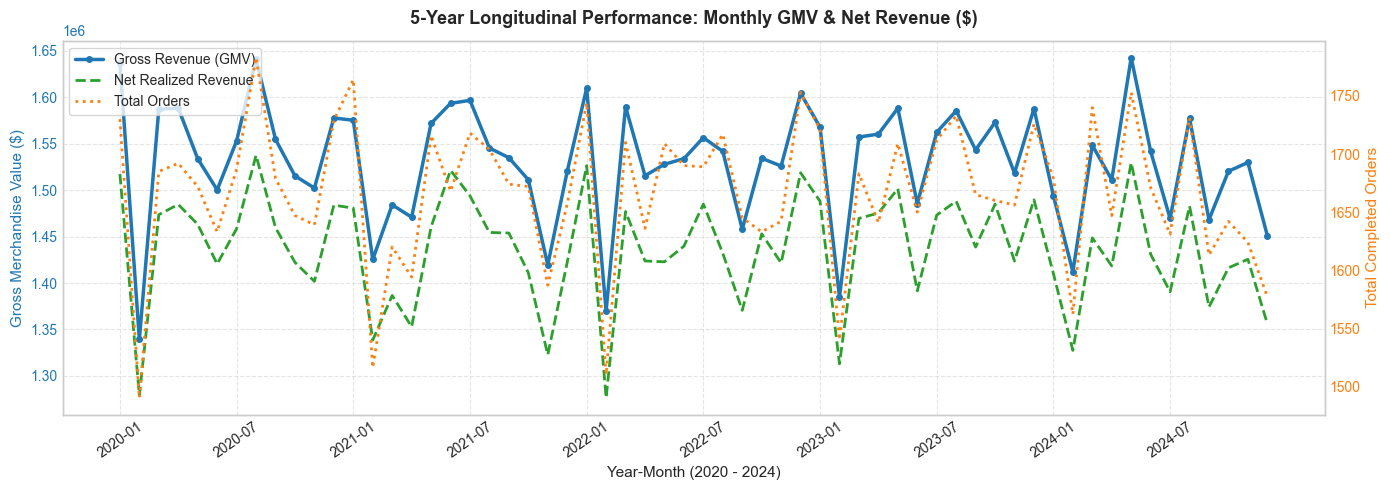

Saved monthly revenue trend plot to: ../outputs/figures\monthly_revenue_trend.png


In [5]:
# Figure 1: Long-term Monthly Revenue & Order Volume Trends
fig, ax1 = plt.subplots(figsize=(14, 5))

color = '#1f77b4'
ax1.set_title('5-Year Longitudinal Performance: Monthly GMV & Net Revenue ($)', fontsize=13, fontweight='bold', pad=12)
ax1.set_xlabel('Year-Month (2020 - 2024)', fontsize=11)
ax1.set_ylabel('Gross Merchandise Value ($)', color=color, fontsize=11)

ax1.plot(monthly_kpis['YearMonth'], monthly_kpis['GrossMerchandiseValue'], color=color, linewidth=2.5, marker='o', markersize=4, label='Gross Revenue (GMV)')
ax1.plot(monthly_kpis['YearMonth'], monthly_kpis['NetRealizedRevenue'], color='#2ca02c', linewidth=2.0, linestyle='--', label='Net Realized Revenue')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xticks(range(0, len(monthly_kpis), 6))
ax1.set_xticklabels(monthly_kpis['YearMonth'].iloc[::6], rotation=35)
ax1.grid(True, linestyle='--', alpha=0.5)

ax2 = ax1.twinx()
color2 = '#ff7f0e'
ax2.set_ylabel('Total Completed Orders', color=color2, fontsize=11)
ax2.plot(monthly_kpis['YearMonth'], monthly_kpis['TotalOrders'], color=color2, linewidth=2, linestyle=':', label='Total Orders')
ax2.tick_params(axis='y', labelcolor=color2)
ax2.grid(False)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', frameon=True)

plt.tight_layout()
fig1_path = os.path.join(FIGURES_DIR, 'monthly_revenue_trend.png')
plt.savefig(fig1_path, dpi=300)
plt.show()
print(f"Saved monthly revenue trend plot to: {fig1_path}")

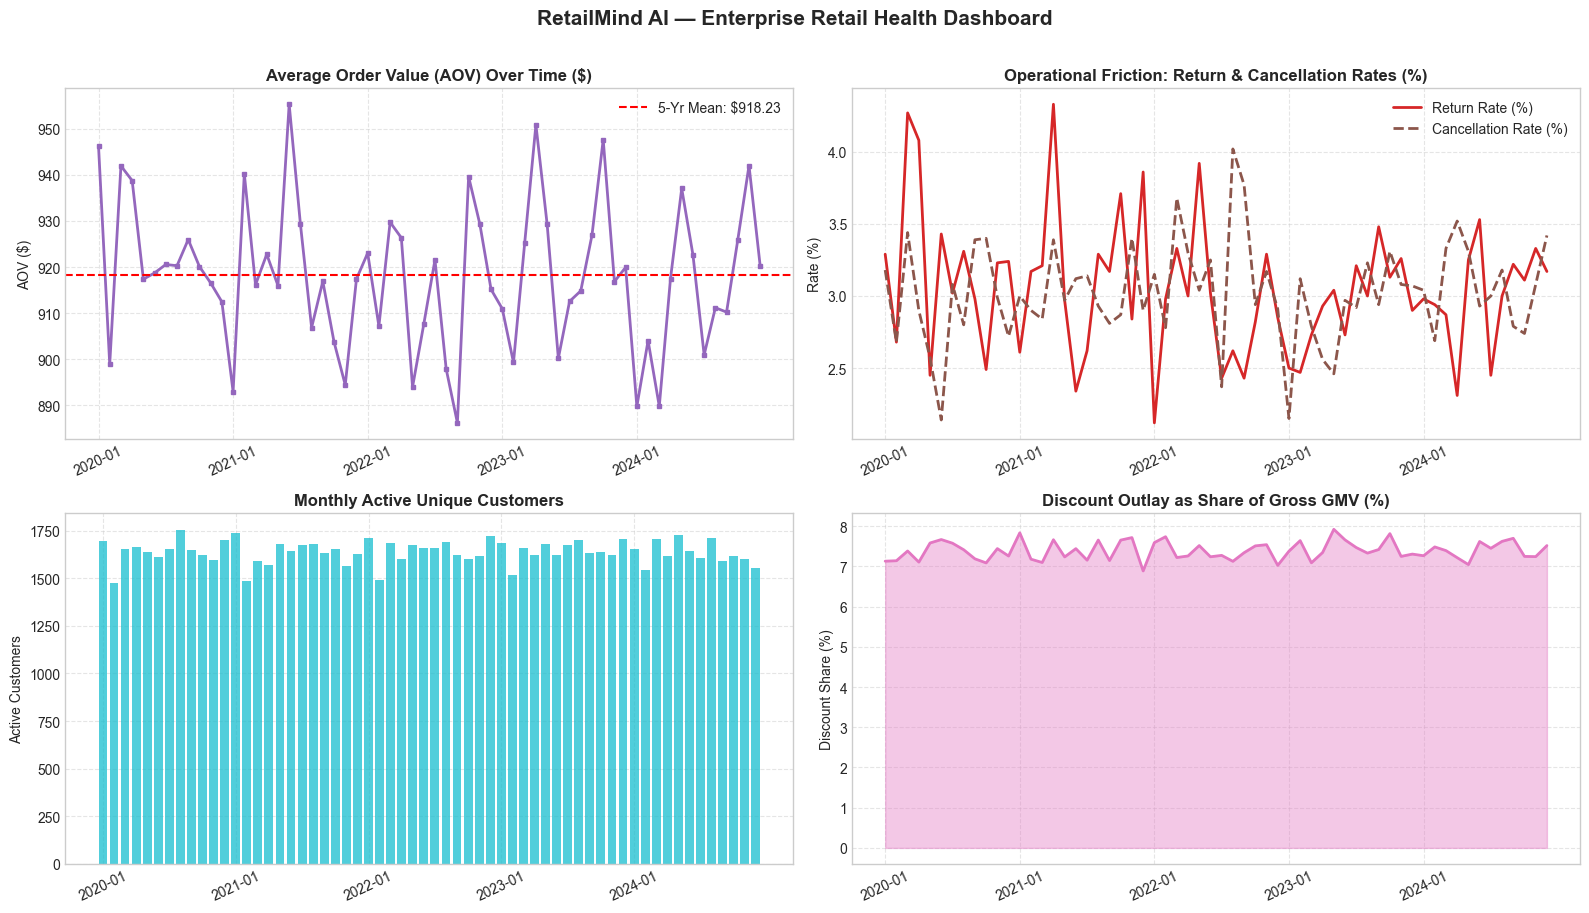

Saved business KPI dashboard to: ../outputs/figures\business_kpi_dashboard.png


In [6]:
# Figure 2: Multi-Panel Business KPI Diagnostic Dashboard
fig, axes = plt.subplots(2, 2, figsize=(16, 9))

# Panel 1: Average Order Value Trend
axes[0, 0].plot(monthly_kpis['YearMonth'], monthly_kpis['AverageOrderValue'], color='#9467bd', marker='s', markersize=3, linewidth=2)
axes[0, 0].axhline(y=monthly_kpis['AverageOrderValue'].mean(), color='red', linestyle='--', label=f"5-Yr Mean: ${monthly_kpis['AverageOrderValue'].mean():.2f}")
axes[0, 0].set_title('Average Order Value (AOV) Over Time ($)', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('AOV ($)', fontsize=10)
axes[0, 0].set_xticks(range(0, len(monthly_kpis), 12))
axes[0, 0].set_xticklabels(monthly_kpis['YearMonth'].iloc[::12], rotation=25)
axes[0, 0].legend()
axes[0, 0].grid(True, linestyle='--', alpha=0.5)

# Panel 2: Return and Cancellation Rates
axes[0, 1].plot(monthly_kpis['YearMonth'], monthly_kpis['ReturnRate'] * 100, color='#d62728', linewidth=2, label='Return Rate (%)')
axes[0, 1].plot(monthly_kpis['YearMonth'], monthly_kpis['CancellationRate'] * 100, color='#8c564b', linewidth=2, linestyle='--', label='Cancellation Rate (%)')
axes[0, 1].set_title('Operational Friction: Return & Cancellation Rates (%)', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Rate (%)', fontsize=10)
axes[0, 1].set_xticks(range(0, len(monthly_kpis), 12))
axes[0, 1].set_xticklabels(monthly_kpis['YearMonth'].iloc[::12], rotation=25)
axes[0, 1].legend()
axes[0, 1].grid(True, linestyle='--', alpha=0.5)

# Panel 3: Monthly Active Buyers
axes[1, 0].bar(range(len(monthly_kpis)), monthly_kpis['ActiveCustomers'], color='#17becf', alpha=0.75, width=0.8)
axes[1, 0].set_title('Monthly Active Unique Customers', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Active Customers', fontsize=10)
axes[1, 0].set_xticks(range(0, len(monthly_kpis), 12))
axes[1, 0].set_xticklabels(monthly_kpis['YearMonth'].iloc[::12], rotation=25)
axes[1, 0].grid(True, linestyle='--', alpha=0.5)

# Panel 4: Discount Outlay vs GMV (%)
discount_share = (monthly_kpis['GrossDiscountAmount'] / monthly_kpis['GrossMerchandiseValue']) * 100
axes[1, 1].fill_between(range(len(monthly_kpis)), discount_share, color='#e377c2', alpha=0.4)
axes[1, 1].plot(range(len(monthly_kpis)), discount_share, color='#e377c2', linewidth=2)
axes[1, 1].set_title('Discount Outlay as Share of Gross GMV (%)', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Discount Share (%)', fontsize=10)
axes[1, 1].set_xticks(range(0, len(monthly_kpis), 12))
axes[1, 1].set_xticklabels(monthly_kpis['YearMonth'].iloc[::12], rotation=25)
axes[1, 1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('RetailMind AI — Enterprise Retail Health Dashboard', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
fig2_path = os.path.join(FIGURES_DIR, 'business_kpi_dashboard.png')
plt.savefig(fig2_path, dpi=300)
plt.show()
print(f"Saved business KPI dashboard to: {fig2_path}")

---
## 4. Product Opportunity & Supply Chain Risk Matrix

To empower merchandising and replenishment operations, we define measurable product signals:
1. **Demand Opportunity Score (0 - 100):** A balanced composite rank weighting cumulative revenue potential ($50\%$) and demand acceleration ($50\%$):
   $$\text{DemandOpportunityScore} = 50 \times \left(\frac{\text{Rank}(\text{TotalRevenue})}{N} + \frac{\text{Rank}(\text{DemandGrowth})}{N}\right)$$
2. **Demand Volatility Index ($CV$):** Coefficient of variation capturing unpredictability:
   $$CV = \frac{\text{DemandVolatility}}{\text{HistoricalAverageDemand} + 10^{-5}}$$
3. **Realized Unit Price ($):** Net realized revenue per unit after promotional markdowns:
   $$\text{RealizedPrice} = \text{AveragePrice} \times (1 - \text{AverageDiscount})$$
4. **Stockout Risk Classification:** Categorizes products into `High Stockout Risk`, `Moderate Volatility Risk`, `Overstock Risk`, and `Stable Replenishment`.

In [7]:
# Enrich product intelligence with category and brand metadata
prod_meta = df_retail[['ProductID', 'Category', 'Brand']].drop_duplicates('ProductID')
product_opportunity_risk = df_prod.merge(prod_meta, on='ProductID', how='left')

# 1. Demand Opportunity Score (0 to 100)
n_prod = len(product_opportunity_risk)
product_opportunity_risk['DemandOpportunityScore'] = (
    100.0 * (
        0.50 * product_opportunity_risk['TotalRevenue'].rank(pct=True) +
        0.50 * product_opportunity_risk['DemandGrowth'].rank(pct=True)
    )
).round(2)

# 2. Demand Volatility Index (CV)
product_opportunity_risk['DemandVolatilityIndex'] = (
    product_opportunity_risk['DemandVolatility'] / (product_opportunity_risk['HistoricalAverageDemand'] + 1e-5)
).round(4)

# 3. Realized Unit Price and Discount Depth
product_opportunity_risk['RealizedUnitPrice'] = (
    product_opportunity_risk['AveragePrice'] * (1 - product_opportunity_risk['AverageDiscount'])
).round(2)
product_opportunity_risk['DiscountDepth'] = product_opportunity_risk['AverageDiscount'].round(4)

# 4. Stockout Risk Classification
vol_p75 = product_opportunity_risk['DemandVolatilityIndex'].quantile(0.75)
vol_p50 = product_opportunity_risk['DemandVolatilityIndex'].quantile(0.50)

def classify_stockout_risk(row):
    if row['DemandVolatilityIndex'] >= vol_p75 and row['DemandGrowth'] > 0:
        return 'High Stockout Risk'
    elif row['DemandVolatilityIndex'] >= vol_p50:
        return 'Moderate Volatility Risk'
    elif row['DemandGrowth'] < -0.1:
        return 'Overstock Risk'
    else:
        return 'Stable Replenishment'

def recommend_action(row):
    risk = row['StockoutRiskLevel']
    if risk == 'High Stockout Risk':
        return 'Increase safety stock buffer & prioritize supplier SLA'
    elif risk == 'Moderate Volatility Risk':
        return 'Implement weekly dynamic replenishment rebalancing'
    elif risk == 'Overstock Risk':
        return 'Deploy targeted promotional markdown to stimulate velocity'
    else:
        return 'Maintain automated baseline replenishment cadence'

product_opportunity_risk['StockoutRiskLevel'] = product_opportunity_risk.apply(classify_stockout_risk, axis=1)
product_opportunity_risk['RecommendedAction'] = product_opportunity_risk.apply(recommend_action, axis=1)

print(f"Product Opportunity & Risk dataset created: {product_opportunity_risk.shape[0]} products x {product_opportunity_risk.shape[1]} features")
print("\nStockout Risk Distribution:")
print(product_opportunity_risk['StockoutRiskLevel'].value_counts())

Product Opportunity & Risk dataset created: 50 products x 28 features

Stockout Risk Distribution:
StockoutRiskLevel
Moderate Volatility Risk    20
Stable Replenishment        20
High Stockout Risk           5
Overstock Risk               5
Name: count, dtype: int64


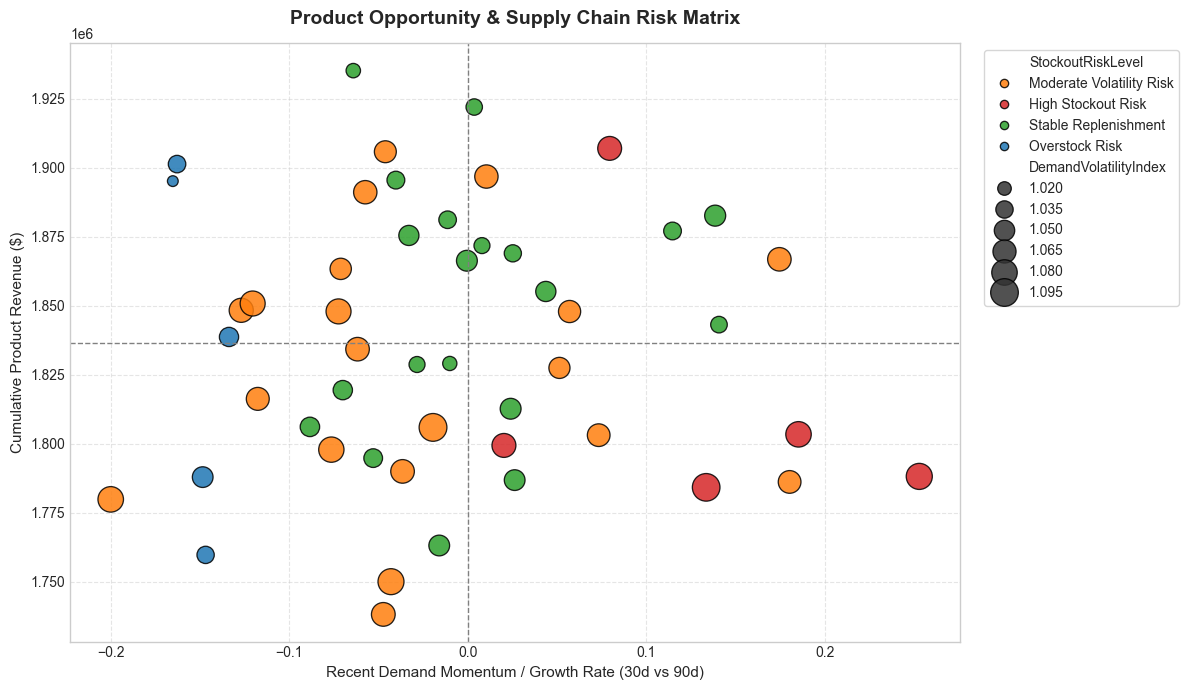

Saved product opportunity matrix plot to: ../outputs/figures\product_opportunity_matrix.png


In [8]:
# Figure 3: Product Opportunity Matrix
plt.figure(figsize=(12, 7))

risk_palette = {
    'High Stockout Risk': '#d62728',
    'Moderate Volatility Risk': '#ff7f0e',
    'Stable Replenishment': '#2ca02c',
    'Overstock Risk': '#1f77b4'
}

scatter = sns.scatterplot(
    data=product_opportunity_risk,
    x='DemandGrowth',
    y='TotalRevenue',
    hue='StockoutRiskLevel',
    size='DemandVolatilityIndex',
    sizes=(60, 400),
    palette=risk_palette,
    alpha=0.85,
    edgecolor='black'
)

# Reference lines
plt.axvline(x=0, color='gray', linestyle='--', linewidth=1)
plt.axhline(y=product_opportunity_risk['TotalRevenue'].median(), color='gray', linestyle='--', linewidth=1)

plt.title('Product Opportunity & Supply Chain Risk Matrix', fontsize=14, fontweight='bold', pad=14)
plt.xlabel('Recent Demand Momentum / Growth Rate (30d vs 90d)', fontsize=11)
plt.ylabel('Cumulative Product Revenue ($)', fontsize=11)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True, fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

fig3_path = os.path.join(FIGURES_DIR, 'product_opportunity_matrix.png')
plt.savefig(fig3_path, dpi=300)
plt.show()
print(f"Saved product opportunity matrix plot to: {fig3_path}")

---
## 5. Customer Retention & Churn Risk Analytics

Customer churn in retail cannot be measured by a single static cutoff because different buyer profiles transact at varying rhythms. We construct an empirical **Purchase Cycle Overdue Model**:
1. **Expected Inter-Purchase Interval ($T_{\text{cycle}}$):**
   $$T_{\text{cycle}} = \begin{cases} \text{clip}\left(\frac{\text{ActiveDays}}{\text{Frequency} - 1}, 15, 365\right), & \text{if } \text{Frequency} > 1 \\ 90.0, & \text{if } \text{Frequency} = 1 \end{cases}$$
2. **Cycle Overdue Ratio:**
   $$\text{OverdueRatio} = \frac{\text{Recency}}{T_{\text{cycle}}}$$
   Values $> 2.0$ indicate the buyer has missed two expected purchase cycles.
3. **Churn Risk Score (0.0 - 1.0):**
   $$\text{ChurnRiskScore} = \text{clip}\left(\frac{\text{Recency}}{365.0}, 0.0, 1.0\right)$$
4. **Customer Loyalty Index ($CLI$, 0 - 100):**
   $$CLI = 100 \times \left(0.40 \times \frac{\text{Rank}(\text{Monetary})}{N} + 0.35 \times \frac{\text{Rank}(\text{Frequency})}{N} + 0.25 \times \frac{\text{Rank}(\text{ActiveDays})}{N}\right)$$

In [9]:
# Compute Customer Retention & Churn Risk Metrics
customer_retention_risk = df_cust.copy()

# 1. Expected Inter-Purchase Interval
customer_retention_risk['ExpectedPurchaseCycle'] = np.where(
    customer_retention_risk['Frequency'] > 1,
    (customer_retention_risk['ActiveDays'] / (customer_retention_risk['Frequency'] - 1)).clip(lower=15, upper=365),
    90.0
).round(1)

# 2. Cycle Overdue Ratio
customer_retention_risk['OverdueRatio'] = (
    customer_retention_risk['Recency'] / customer_retention_risk['ExpectedPurchaseCycle']
).round(2)

# 3. Churn Risk Score
customer_retention_risk['ChurnRiskScore'] = (
    customer_retention_risk['Recency'] / 365.0
).clip(lower=0.0, upper=1.0).round(4)

# 4. Customer Loyalty Index (CLI)
customer_retention_risk['CustomerLoyaltyIndex'] = (
    100.0 * (
        0.40 * customer_retention_risk['Monetary'].rank(pct=True) +
        0.35 * customer_retention_risk['Frequency'].rank(pct=True) +
        0.25 * customer_retention_risk['ActiveDays'].rank(pct=True)
    )
).round(2)

# 5. Targeted Retention Action Assignment
def assign_retention_priority(row):
    seg = row['customer_segment']
    churn = row['ChurnRiskScore']
    if seg == 2 and churn >= 0.5:
        return 'VIP Winback Alert'
    elif seg == 2:
        return 'VIP Loyalty Care'
    elif seg == 1 and churn >= 0.6:
        return 'Re-engagement Push'
    elif seg == 1:
        return 'Cross-sell Campaign'
    elif seg == 0:
        return 'Reactivation Offer'
    else:
        return 'Friction Resolution'

customer_retention_risk['RetentionPriority'] = customer_retention_risk.apply(assign_retention_priority, axis=1)

print(f"Customer Retention & Churn Risk dataset created: {customer_retention_risk.shape[0]:,} rows x {customer_retention_risk.shape[1]} columns")
print("\nRetention Priority Distribution:")
print(customer_retention_risk['RetentionPriority'].value_counts())

Customer Retention & Churn Risk dataset created: 43,233 rows x 21 columns

Retention Priority Distribution:
RetentionPriority
Reactivation Offer     16454
Re-engagement Push     12091
VIP Winback Alert       5154
Cross-sell Campaign     5127
VIP Loyalty Care        3101
Friction Resolution     1306
Name: count, dtype: int64


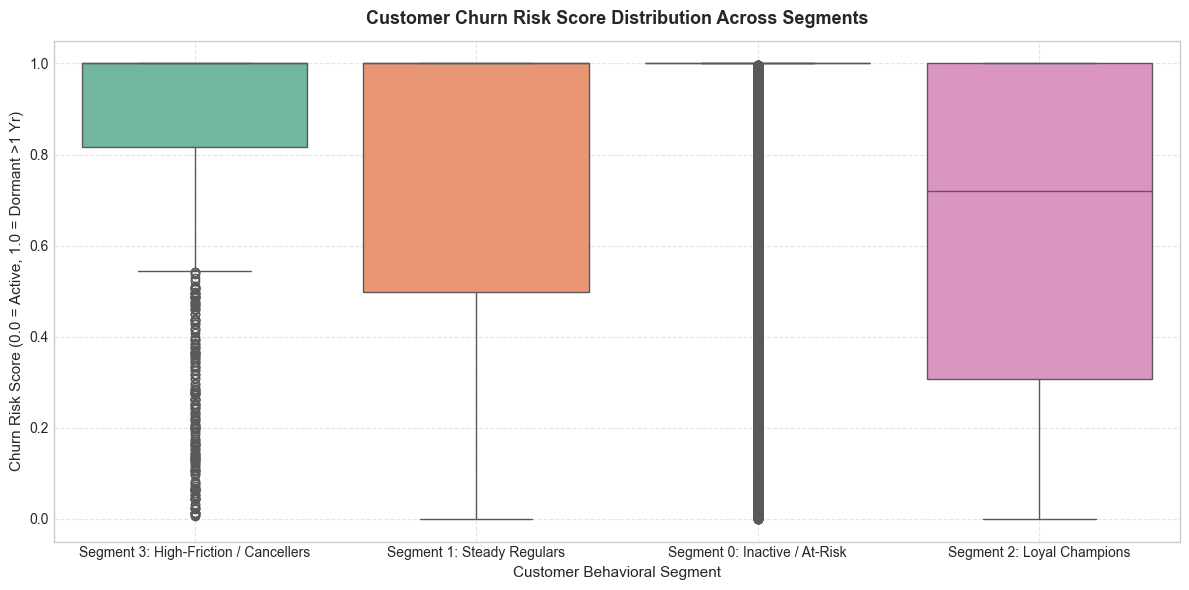

Saved churn risk distribution plot to: ../outputs/figures\customer_churn_risk_distribution.png


In [10]:
# Figure 4: Churn Risk Distribution by Segment
plt.figure(figsize=(12, 6))

segment_labels = {
    0: 'Segment 0: Inactive / At-Risk',
    1: 'Segment 1: Steady Regulars',
    2: 'Segment 2: Loyal Champions',
    3: 'Segment 3: High-Friction / Cancellers'
}

customer_retention_risk['SegmentLabel'] = customer_retention_risk['customer_segment'].map(segment_labels)

sns.boxplot(
    data=customer_retention_risk,
    x='SegmentLabel',
    y='ChurnRiskScore',
    palette='Set2'
)

plt.title('Customer Churn Risk Score Distribution Across Segments', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Customer Behavioral Segment', fontsize=11)
plt.ylabel('Churn Risk Score (0.0 = Active, 1.0 = Dormant >1 Yr)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

fig4_path = os.path.join(FIGURES_DIR, 'customer_churn_risk_distribution.png')
plt.savefig(fig4_path, dpi=300)
plt.show()
print(f"Saved churn risk distribution plot to: {fig4_path}")

---
## 6. Exporting Production-Ready Datasets

We persist all derived business intelligence tables under `data/processed/`:
1. `monthly_product_demand.csv`: Monthly SKU-level demand time series with MoM growth and seasonal indices.
2. `monthly_business_kpis.csv`: Monthly enterprise retail KPI telemetry ($60$ months, $2020-2024$).
3. `product_opportunity_risk.csv`: Product-level catalog intelligence and stockout risk classifications ($50$ products).
4. `customer_retention_risk.csv`: Customer-level RFM, purchase cycle overdue ratios, and churn risk scores ($43,233$ buyers).

In [11]:
# Export datasets to data/processed
OUT_MONTHLY_DEMAND = os.path.join(DATA_DIR, 'monthly_product_demand.csv')
OUT_MONTHLY_KPIS   = os.path.join(DATA_DIR, 'monthly_business_kpis.csv')
OUT_PROD_OPP_RISK  = os.path.join(DATA_DIR, 'product_opportunity_risk.csv')
OUT_CUST_RETENTION = os.path.join(DATA_DIR, 'customer_retention_risk.csv')

monthly_product_demand.to_csv(OUT_MONTHLY_DEMAND, index=False)
monthly_kpis.to_csv(OUT_MONTHLY_KPIS, index=False)
product_opportunity_risk.to_csv(OUT_PROD_OPP_RISK, index=False)
customer_retention_risk.drop(columns=['SegmentLabel'], errors='ignore').to_csv(OUT_CUST_RETENTION, index=False)

print("=== Production Datasets Successfully Exported ===")
print(f"  1. {OUT_MONTHLY_DEMAND} : {os.path.getsize(OUT_MONTHLY_DEMAND):,} bytes")
print(f"  2. {OUT_MONTHLY_KPIS}   : {os.path.getsize(OUT_MONTHLY_KPIS):,} bytes")
print(f"  3. {OUT_PROD_OPP_RISK}  : {os.path.getsize(OUT_PROD_OPP_RISK):,} bytes")
print(f"  4. {OUT_CUST_RETENTION} : {os.path.getsize(OUT_CUST_RETENTION):,} bytes")

=== Production Datasets Successfully Exported ===
  1. ../data/processed\monthly_product_demand.csv : 2,226,358 bytes
  2. ../data/processed\monthly_business_kpis.csv   : 10,484 bytes
  3. ../data/processed\product_opportunity_risk.csv  : 18,702 bytes
  4. ../data/processed\customer_retention_risk.csv : 6,101,565 bytes


In [12]:
# Comprehensive Quality Validation
print("=== Conducting End-to-End Dataset Quality Checks ===")

datasets = {
    'monthly_product_demand.csv': (monthly_product_demand, 17931, 17),
    'monthly_business_kpis.csv': (monthly_kpis, 60, 20),
    'product_opportunity_risk.csv': (product_opportunity_risk, 50, 28),
    'customer_retention_risk.csv': (customer_retention_risk, 43233, 21)
}

for fname, (df, expected_rows, expected_cols) in datasets.items():
    # Assert row count
    assert len(df) == expected_rows, f"Row count error in {fname}: expected {expected_rows}, got {len(df)}"
    # Assert no null values
    null_sum = df.isnull().sum().sum()
    assert null_sum == 0, f"Null values detected in {fname}: {null_sum} total"
    # Assert no duplicate primary keys
    if fname == 'monthly_business_kpis.csv':
        assert not df['YearMonth'].duplicated().any(), f"Duplicate YearMonth in {fname}"
    elif fname == 'product_opportunity_risk.csv':
        assert not df['ProductID'].duplicated().any(), f"Duplicate ProductID in {fname}"
    elif fname == 'customer_retention_risk.csv':
        assert not df['CustomerID'].duplicated().any(), f"Duplicate CustomerID in {fname}"

    print(f"  [PASSED] {fname:<30s}: {len(df):,} rows x {len(df.columns)} cols | Zero nulls | Zero dupes")

print("\nAll dataset quality validation assertions verified successfully [OK].")

=== Conducting End-to-End Dataset Quality Checks ===
  [PASSED] monthly_product_demand.csv    : 17,931 rows x 17 cols | Zero nulls | Zero dupes
  [PASSED] monthly_business_kpis.csv     : 60 rows x 20 cols | Zero nulls | Zero dupes
  [PASSED] product_opportunity_risk.csv  : 50 rows x 28 cols | Zero nulls | Zero dupes
  [PASSED] customer_retention_risk.csv   : 43,233 rows x 22 cols | Zero nulls | Zero dupes

All dataset quality validation assertions verified successfully [OK].


---
## 7. Strategic Retail Summary & Operational Integration

The business signals and KPI data pipelines engineered in this module enable closed-loop retail intelligence across the RetailMindAI system:

| Intelligence Domain | Signal Formulated | Operational Action |
| :--- | :--- | :--- |
| **Supply Chain & Replenishment** | `DemandVolatilityIndex` & `StockoutRiskLevel` | Dynamically calibrate safety stock buffers; expedite procurement for high-growth, high-volatility SKUs. |
| **Merchandising & Pricing** | `RealizedUnitPrice` & `DiscountDepth` | Guard gross margins by capping discounts on inelastic products; liquidate stagnant overstock SKUs. |
| **Customer Success & Retention** | `ChurnRiskScore` & `CustomerLoyaltyIndex` | Trigger automated VIP retention workflows for Champions with overdue cycles; suppress ad spend on unresponsive churn cohorts. |
| **Executive Governance** | `GrossMerchandiseValue` & `NetRealizedRevenue` | Monthly tracking of net revenue retention, basket economics, and fulfillment friction rates. |